# Part 1

Our analysis try to unerstand patterns inside the transactions of different companies.

## Fact Grain

Each row in Fact_Transaction rappresent a single transaction, that can be buy or sell,along with its date and which company does it.

## Tree Schema


In [30]:
from IPython.display import Image
Image(url="tree_schema.png", width=1000, height=500)


## Identify fact and dimensions

- Fact_Transactions: Unit, IDTransaction

- Dim_Time: Date

- Dim_Geography: name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code

- Dim_Symbol: symbol, company_name, industry, sector 

- Dim_TransactionType: Transaction type

## Dimension Hierarchies

- Dim_Time: Day -> Month -> Quarter -> Year 
- Dim_Geography: Country -> Sub-region -> Region  
- Dim_Symbol : Symbol -> Company -> Industria -> Sector 

## Star Schema

- Primary key in blu
- Foreign key in red
- Descriptive attributes in white
- Measures in green

In [31]:
from IPython.display import Image
Image(url="Star_schema.png", width=500, height=500)


# Part 2

### Step 2.1

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Plot features.
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

import os
print(os.getcwd())

df_t = pd.read_csv("Data/Account-statement-1-1-2024-12-31-2024.csv", sep=';')
df_c = pd.read_csv("Data/country.csv", sep=',')
df_s = pd.read_csv("Data/symbols.csv", sep=';')


c:\Users\Andrea\Desktop\Magistrale data science\Primo anno\Big Data\Scripts\13-04\Andrea-Isaia-BDA2026\Homework3


In [33]:
# Checking the null values
summary_t = pd.DataFrame({
    "column" : df_t.columns,
    "dtype" : df_t.dtypes.astype(str).values,
    "missing_values" : df_t.isna().sum().values,
})

summary_c = pd.DataFrame({
    "column" : df_c.columns,
    "dtype" : df_c.dtypes.astype(str).values,
    "missing_values" : df_c.isna().sum().values,
})

summary_s = pd.DataFrame({
    "column" : df_s.columns,
    "dtype" : df_s.dtypes.astype(str).values,
    "missing_values" : df_s.isna().sum().values,
})

print(f"Number of row for transaction dataframe: {df_t.shape[0]}")
print("Summary of transactions dataframe")
print(summary_t)

print(f"\nNumber of row for country dataframe: {df_c.shape[0]}")
print("Summary of country dataframe")
print(summary_c)

print(f"\nNumber of row for symbols dataframe: {df_s.shape[0]}")
print("Summary of symbols dataframe")
print(summary_s)


Number of row for transaction dataframe: 2745
Summary of transactions dataframe
            column    dtype  missing_values
0    IDTransaction  float64             464
1             Date   object             464
2  TransactionType   object             464
3           Symbol   object             464
4             Unit  float64             464
5       Unnamed: 5  float64            2745

Number of row for country dataframe: 249
Summary of country dataframe
                      column    dtype  missing_values
0                       name   object               0
1                    alpha-2   object               1
2                    alpha-3   object               0
3               country-code    int64               0
4                 iso_3166-2   object               0
5                     region   object               2
6                 sub-region   object               2
7        intermediate-region   object             144
8                region-code  float64               2
9

Apparently, the transaction dataframe has 464 missing values and 2745 missing values for an "Unnamed" feature. This is due to a mistake during the CSV creation: first of all, at the end of the file, there are 464 ";;;;;" rows that Pandas recognizes as actual rows. Furthermore, at the end of each valid line, there is an extra ";", which explains why another column named "Unnamed" was created.

For our analysis, we do not need the subregion or the intermediate region, so the presence of missing values fot them doesn't matter. Now we will check the missing values specifically for 'alpha-2' and 'region' to better understand why they are missing.

In [34]:
print(df_c[df_c["alpha-2"].isna()])
print("\n")
print(df_c[df_c["region"].isna()])


        name alpha-2 alpha-3  country-code     iso_3166-2  region  \
153  Namibia     NaN     NAM           516  ISO 3166-2:NA  Africa   

             sub-region intermediate-region  region-code  sub-region-code  \
153  Sub-Saharan Africa     Southern Africa          2.0            202.0   

     intermediate-region-code  
153                      18.0  


                          name alpha-2 alpha-3  country-code     iso_3166-2  \
8                   Antarctica      AQ     ATA            10  ISO 3166-2:AQ   
217  Taiwan, Province of China      TW     TWN           158  ISO 3166-2:TW   

    region sub-region intermediate-region  region-code  sub-region-code  \
8      NaN        NaN                 NaN          NaN              NaN   
217    NaN        NaN                 NaN          NaN              NaN   

     intermediate-region-code  
8                         NaN  
217                       NaN  


We can see that for the 'alpha-2' code, only Namibia has missing values; therefore, we will use 'alpha-3' for our analysis instead. The region 'Antarctica' can be removed from the dataset. Additionally, Taiwan lacks both a 'region-code' and a 'region'. This is likely due to geopolitical and geo-economic reasons; however, since we know it is located in Asia, we will manually update these missing fields to ensure our data is complete.

In [35]:
# Deleteing Antarctica.
df_c = df_c[df_c["name"] != "Antarctica"]

# Modifing Taiwan.
df_c.loc[df_c["name"] == "Taiwan, Province of China", "region"] = "Asia"
df_c.loc[df_c["name"] == "Taiwan, Province of China", "region-code"] = df_c[df_c["name"] == "China"]["region-code"].values

# Small check.
print(df_c[df_c["name"] == "Taiwan, Province of China"]) 

# Removing unused columns.
df_c = df_c[["name","region","alpha-3"]]


                          name alpha-2 alpha-3  country-code     iso_3166-2  \
217  Taiwan, Province of China      TW     TWN           158  ISO 3166-2:TW   

    region sub-region intermediate-region  region-code  sub-region-code  \
217   Asia        NaN                 NaN        142.0              NaN   

     intermediate-region-code  
217                       NaN  


In [36]:
# Removing all rows where all features have NA values in the transaction dataframe.
print(f"Number of rows for transaction dataframe: {df_t.shape[0]}")
df_t.dropna(how = "all",inplace=True)

# Small check.
print(f"Number of rows for transaction dataframe after the removing operation: {df_t.shape[0]}")

# Removing Unnamed column.
df_t = df_t[df_t.columns.values[:-1]]


Number of rows for transaction dataframe: 2745
Number of rows for transaction dataframe after the removing operation: 2281


In [37]:
# Verifying if each symbol in the transactions dataframe has a correspondent 
# inside the symbols dataframe. We use a left join to have NA in features
# that doesn't have a value.
symbols_not_inside = df_t[~df_t["Symbol"].isin(df_s["symbol"])]
print(f"Number of rows for transaction dataframe that have no symbol in symbols dataframe: {symbols_not_inside.shape[0]}")

# Another possibility is to delete these rows. This can be done 
# with the line of code below.
# df_t = df_t[df_t["Symbol"].isin(df_s["symbol"])]

# Small check.
print(f"Number of rows for transaction dataframe: {df_t.shape[0]}")

# Verifying if each country in the symbols dataframe has a correspondent
# inside the country dataframe.
country_not_inside= df_s[~df_s["country"].isin(df_c["name"])]
print(f"\nNumber of rows for symbols dataframe that have no country in country dataframe: {country_not_inside.shape[0]}")
print(country_not_inside["country"])

# Small check.
print(f"Number of rows for symbols dataframe: {df_s.shape[0]}")

# There are different names, therefore we change it with the same.
df_s.replace("Taiwan","Taiwan, Province of China",inplace= True)
df_s.replace("Turkey","Türkiye",inplace= True)



Number of rows for transaction dataframe that have no symbol in symbols dataframe: 212
Number of rows for transaction dataframe: 2281

Number of rows for symbols dataframe that have no country in country dataframe: 7
316    Taiwan
317    Taiwan
318    Taiwan
319    Taiwan
320    Taiwan
321    Taiwan
323    Turkey
Name: country, dtype: object
Number of rows for symbols dataframe: 3194


In [38]:
# Renaming symbol column to have the same name. 
df_t.rename(columns={"Symbol":"symbol"}, inplace=True)

# Doing left join on symbol.
df = pd.merge(df_t,df_s, on= "symbol", how= "left")

# Small check.
print(df.head())

# Renaiming name column with country.
df_c.rename(columns={"name":"country"},inplace=True)

# Doing left join on country.
df = pd.merge(df,df_c,on="country",how="left")

# Seeing the rows with NA.
print(df[df.isna().any(axis=1)])

# Filling all the NA values with "Unknow"
# If we wont to delete the rows, we have to cancel the line below.
df.fillna("Unknown", inplace=True)

# Small check
print("\n",df.head())

# Seeing if NA is changed. It should give an empty list.
print(df[df.isna().any(axis=1)])




   IDTransaction                 Date TransactionType symbol    Unit  \
0   2.769834e+09  11/01/2024 10:44:03             BUY    BAP  1605.0   
1   2.767325e+09  24/01/2024 08:07:24            SELL    BAP  1605.0   
2   2.815474e+09  10/01/2024 11:00:08            SELL    BAP   914.0   
3   2.622244e+09  16/01/2024 08:14:21             BUY   ACGL   646.0   
4   2.629871e+09  16/01/2024 14:34:12            SELL   ALVO   646.0   

              company_name              sector  \
0           Credicorp Ltd.  Financial Services   
1           Credicorp Ltd.  Financial Services   
2           Credicorp Ltd.  Financial Services   
3  Arch Capital Group Ltd.  Financial Services   
4                 Alvotech          Healthcare   

                                   industry     country  
0                          Banks - Regional        Peru  
1                          Banks - Regional        Peru  
2                          Banks - Regional        Peru  
3                   Insurance - Di

      IDTransaction                 Date TransactionType symbol   Unit  \
34     2.720406e+09  28/02/2024 20:53:36             BUY    MFG  202.0   
35     2.680927e+09  04/03/2024 18:24:59            SELL    MFG  202.0   
45     2.666427e+09  11/03/2024 14:17:28             BUY    MFG  185.0   
46     2.699918e+09  09/05/2024 07:00:02             BUY  AGO.l  185.0   
47     2.770674e+09  01/04/2024 14:02:13            SELL    MFG  185.0   
...             ...                  ...             ...    ...    ...   
1879   2.711335e+09  20/11/2024 00:26:44        DIVIDENT   HTGC   46.0   
1886   2.497267e+09  16/12/2024 00:45:08        DIVIDENT    MFG   45.0   
1894   2.678621e+09  09/10/2024 13:30:12            SELL    MFG   45.0   
1913   2.631014e+09  01/02/2024 11:12:03            SELL   MONC   42.0   
2045   2.631015e+09  04/01/2024 08:00:17            SELL   MONC   26.0   

     company_name sector industry country region alpha-3  
34            NaN    NaN      NaN     NaN    NaN    

### Step 2.2

1. What are the top 5 sectors by number of SELL transactions in US during 2024? 

                        n_for_sector
sector                              
Technology                       158
Communication Services            58
Financial Services                55
Healthcare                        50
Consumer Cyclical                 48


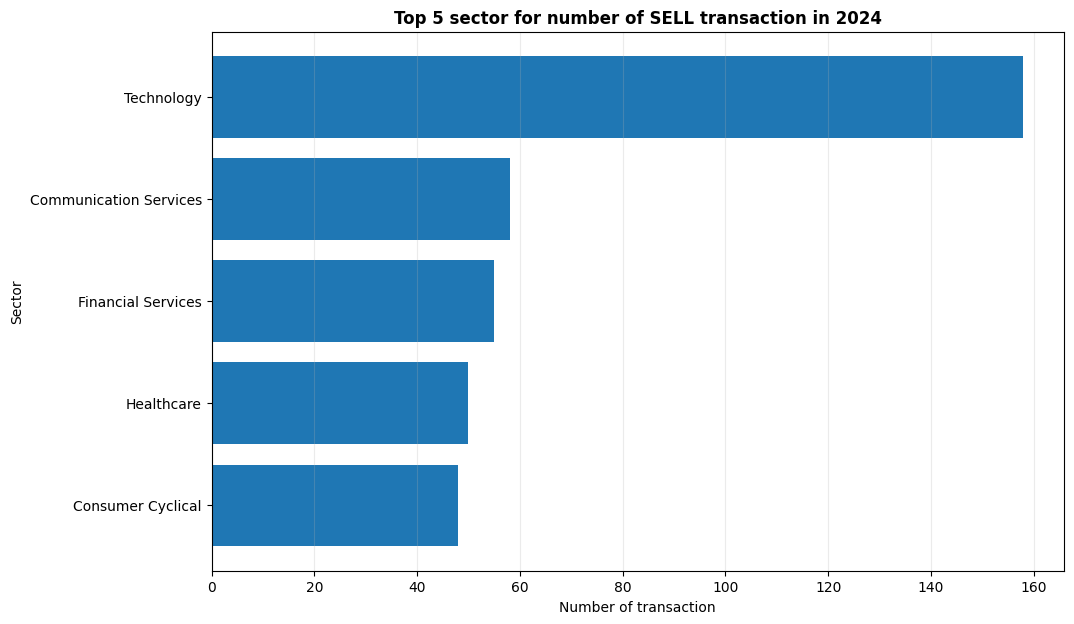

In [39]:
# Finding in the US the sector with the higest number of SELL transaction.
df_america = df[df["country"] == "United States of America"].copy()
df_america = df_america[df_america["TransactionType"] == "SELL"]
df_america = df_america.groupby("sector").agg(
    n_for_sector = ("sector","count")
).nlargest(5,"n_for_sector")

# Seeing the result.
print(df_america)

# Creating a bar plot to rapresent.
df_america = df_america.sort_values("n_for_sector",ascending=True)
fig, ax = plt.subplots(figsize = (11,7)) 
ax.barh(
    df_america.index,
    df_america["n_for_sector"],
)
ax.set_title("Top 5 sector for number of SELL transaction in 2024")
ax.set_xlabel("Number of transaction")
ax.set_ylabel("Sector")
ax.grid(axis="x",alpha=0.25)



2. What are the top 10 countries by number of SELL transactions in 2024? 

         n_sell
alpha-3        
USA         389
GBR         130
CHN         112
Unknown     100
BRA          69
TWN          50
NLD          46
CHE          37
IRL          31
LUX          27


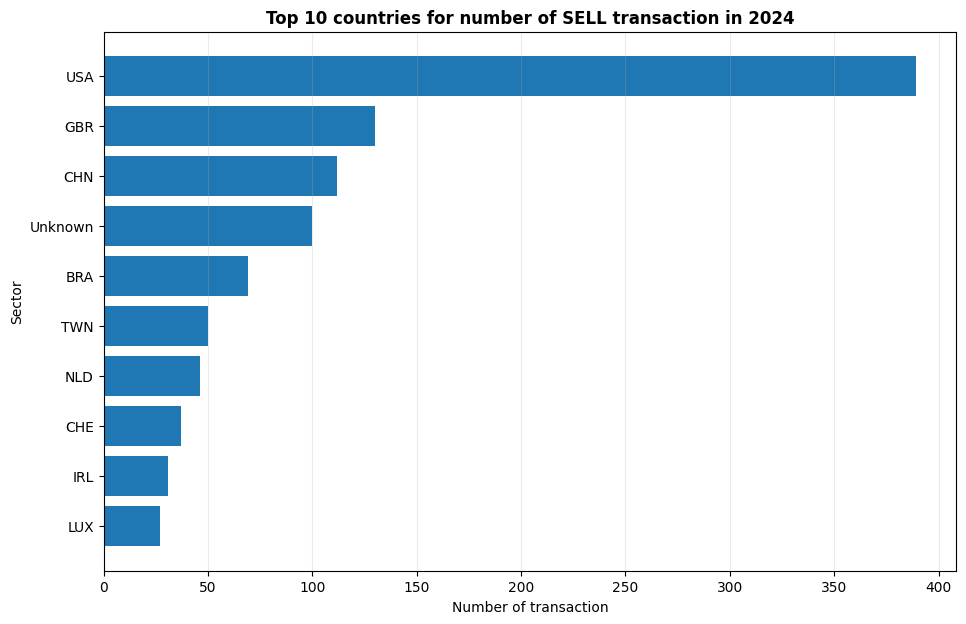

In [40]:
df_countries = df[df["TransactionType"] == "SELL"].groupby("alpha-3").agg(
    n_sell = ("TransactionType","count")
).nlargest(10,"n_sell").copy()

# Seeing the result.
print(df_countries)

# Creating a bar plot to rapresent.
df_countries = df_countries.sort_values("n_sell",ascending=True)
fig, ax = plt.subplots(figsize = (11,7)) 
ax.barh(
    df_countries.index,
    df_countries["n_sell"],
)
ax.set_title("Top 10 countries for number of SELL transaction in 2024")
ax.set_xlabel("Number of transaction")
ax.set_ylabel("Sector")
ax.grid(axis="x",alpha=0.25)


3. What are the top 5 sectors by total units traded (BUY + SELL) in Q3 of 2024? 

Q3: July 1 – September 30

                        tot_units
sector                           
Technology                 4461.0
Healthcare                 3572.0
Consumer Cyclical          2667.0
Financial Services         2054.0
Communication Services     1863.0


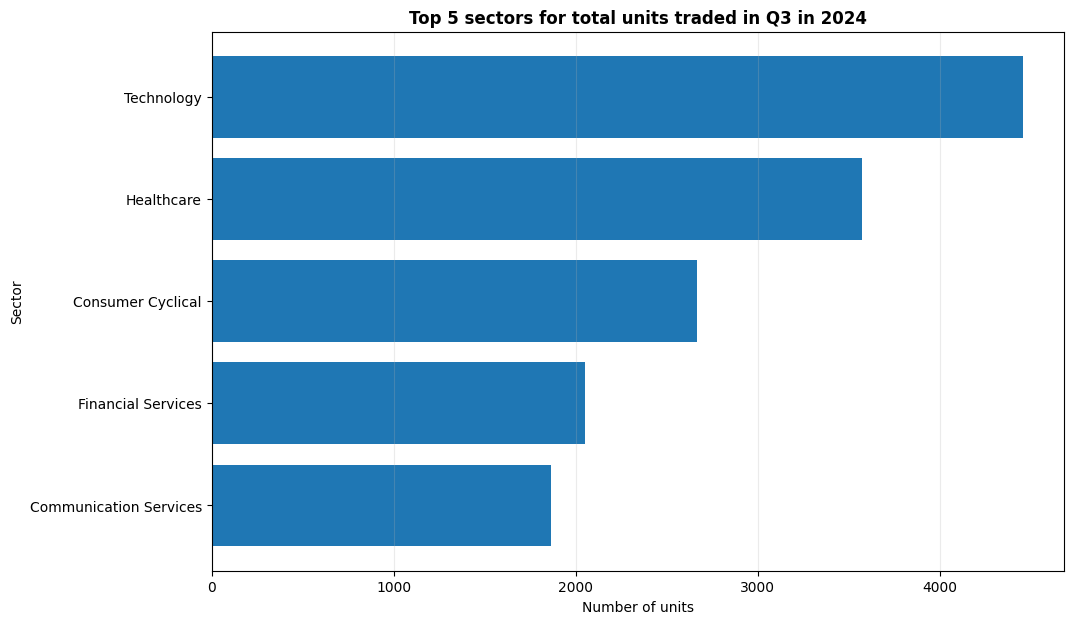

In [41]:
from datetime import datetime

# Frist changing string format of date in datetime format.
df["Date"] = pd.to_datetime(df["Date"],dayfirst = True,errors="coerce")

# Creating the dataframe for Q3.
df_Q3 = df[(df["Date"] <= datetime(2024,9,30,23,59)) & (df["Date"] >= datetime(2024,7,1,0,0))].copy()

# Taking only SELL and BUY.
df_Q3 = df_Q3[(df_Q3["TransactionType"] == "SELL") | (df_Q3["TransactionType"] == "BUY")]

# Taking total units.
df_Q3 = df_Q3.groupby("sector").agg(tot_units = ("Unit","sum")).nlargest(5,"tot_units")

# Seeing the result.
print(df_Q3)

# Creating a bar plot to rapresent.
df_Q3 = df_Q3.sort_values("tot_units",ascending=True)
fig, ax = plt.subplots(figsize = (11,7)) 
ax.barh(
    df_Q3.index,
    df_Q3["tot_units"],
)
ax.set_title("Top 5 sectors for total units traded in Q3 in 2024")
ax.set_xlabel("Number of units")
ax.set_ylabel("Sector")
ax.grid(axis="x",alpha=0.25)


4. What are the top 5 countries by number of units traded in Financial Services companies? 

                          tot_units
country                            
United States of America     7352.0
Peru                         4434.0
Bermuda                      3658.0
China                        1663.0
Canada                       1466.0


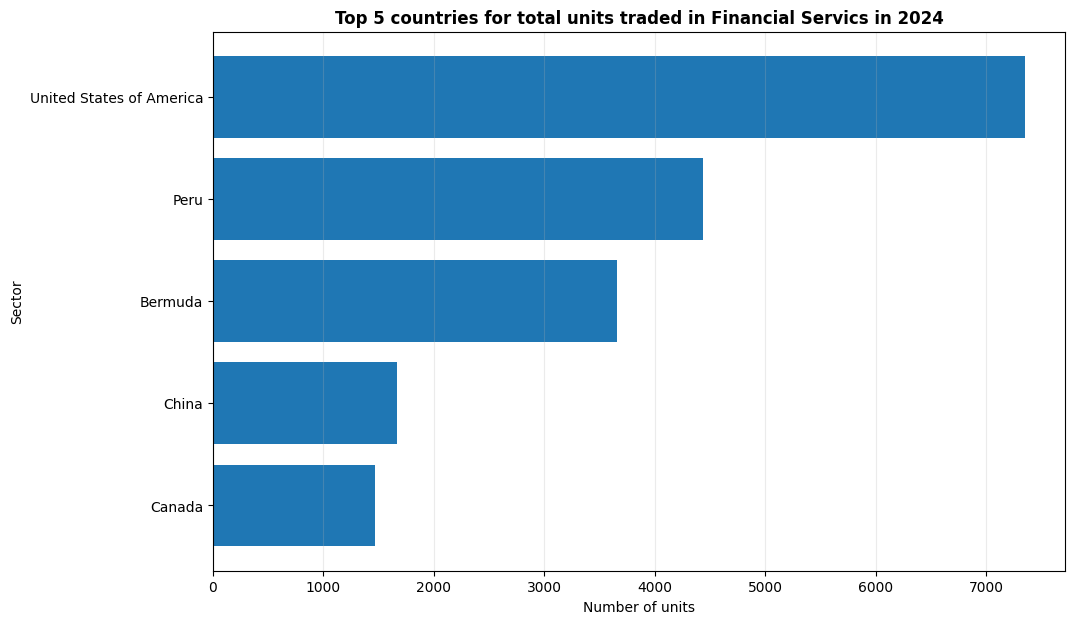

In [42]:
# Chosing Financial Services as sector.
df_fs = df[df["sector"] == "Financial Services"].copy()

# rouping by countri and doing the sum over units.
df_fs = df_fs.groupby("country").agg(tot_units=("Unit","sum")).nlargest(5,"tot_units")

#Seeing the result.
print(df_fs)

# Creating a bar plot to rapresent.
df_fs = df_fs.sort_values("tot_units",ascending=True)
fig, ax = plt.subplots(figsize = (11,7)) 
ax.barh(
    df_fs.index,
    df_fs["tot_units"],
)
ax.set_title("Top 5 countries for total units traded in Financial Servics in 2024")
ax.set_xlabel("Number of units")
ax.set_ylabel("Sector")
ax.grid(axis="x",alpha=0.25)


5. What are the top 5 industries by units traded in Asia in 2024? 

                                tot_units
industry                                 
Semiconductors                     5553.0
Auto Manufacturers                 4769.0
Diagnostics & Research             1945.0
Internet Content & Information     1805.0
Aerospace & Defense                1799.0


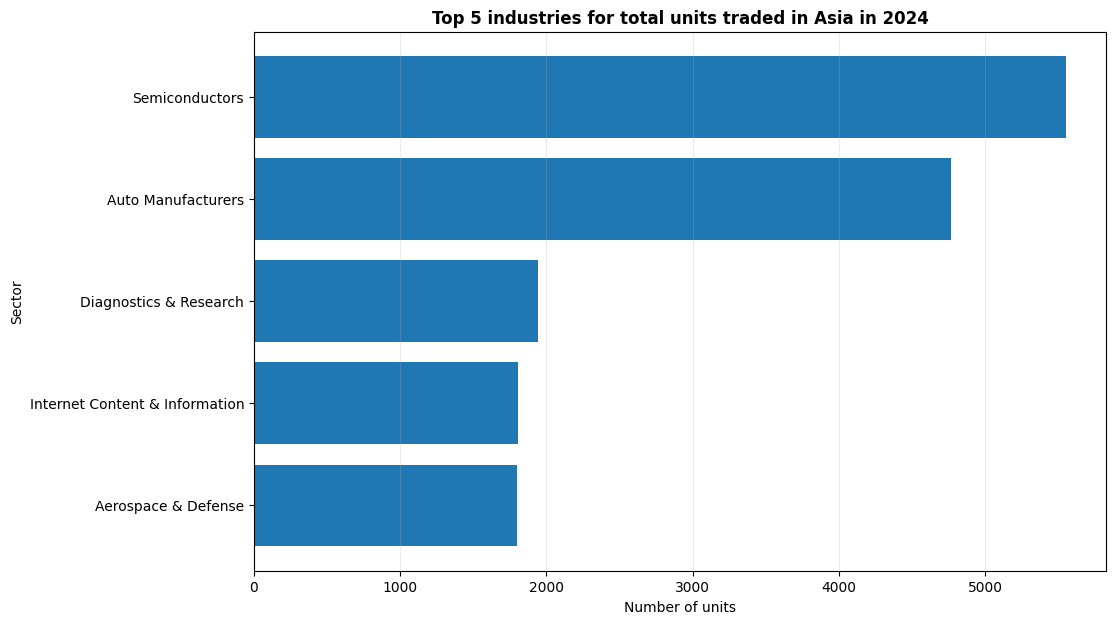

In [43]:
# Selecting only rows with Asia as region.
df_Asia = df[df["region"] == "Asia"].copy()

# Counting the units for insutry in Asia.
df_Asia = df_Asia.groupby("industry").agg(tot_units = ("Unit","sum")).nlargest(5,"tot_units")

# Seeing the result.
print(df_Asia)

# Creating a bar plot to rapresent.
df_Asia = df_Asia.sort_values("tot_units",ascending=True)
fig, ax = plt.subplots(figsize = (11,7)) 
ax.barh(
    df_Asia.index,
    df_Asia["tot_units"],
)
ax.set_title("Top 5 industries for total units traded in Asia in 2024")
ax.set_xlabel("Number of units")
ax.set_ylabel("Sector")
ax.grid(axis="x",alpha=0.25)


In [44]:
# Creating a csv for saving the dataframe used in this exercise if it doesn't exist.
from pathlib import Path
path = Path("Streamlit/Data/Fact_Transactions.csv")

if not path.exists():
    df.to_csv('Streamlit/Data/Fact_Transactions.csv', sep=';', index=False)
else:
    print("The file already exists")


The file already exists
